# CLO DUAL JSON MAKER COVER ARC DATA 
Centerpoint 기준으로 arrangement point하지 않고

각 패널의 Mean Point를 기준으로 arrangement point 생성

++ 추가적으로 ARC 2 Bezier data에 대해서도 다룰 수 있게 됨.ㅋ.ㅋ

In [1]:
import os, sys
sys.path.append(os.path.dirname(os.getcwd()))
from glob import glob
import math
from pprint import pprint
import torch

import pygarment as pyg
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import time

from tqdm import tqdm
import json
import random

import trimesh
from ANALYSIS.analysis_utils import (
    plot_panel_info,
    visualize_meshes_plotly,
    v_id_map
)


In [11]:
batch_points = {
"Arm_Back_1_L" : [ 20.4240,  132.30371, -15.25501],
"Arm_Back_2_L" : [ 25.4240,  127.80371, -15.25501],
"Arm_Back_3_L" : [ 30.4240,  123.30371, -15.25501],
"Arm_Back_4_L" : [ 35.4240,  118.80371, -15.25501],
"Arm_Back_5_L" : [ 40.4240,  114.30371, -15.25501],
"Arm_Back_6_L" : [ 45.4240,  109.80371, -15.25501],
"Arm_Back_7_L" : [ 50.4240,  105.30371, -15.25501],
"Arm_Back_8_L" : [ 55.4240,  100.80371, -15.25501],
"Arm_Back_1_R" : [ -20.4240,  132.30371, -15.25501],
"Arm_Back_2_R" : [ -25.4240,  127.80371, -15.25501],
"Arm_Back_3_R" : [ -30.4240,  123.30371, -15.25501],
"Arm_Back_4_R" : [ -35.4240,  118.80371, -15.25501],
"Arm_Back_5_R" : [ -40.4240,  114.30371, -15.25501],
"Arm_Back_6_R" : [ -45.4240,  109.80371, -15.25501],
"Arm_Back_7_R" : [ -50.4240,  105.30371, -15.25501],
"Arm_Back_8_R" : [ -55.4240,  100.80371, -15.25501],
"Arm_Front_1_L" : [ 20.4240,  132.30371, 15.25501],
"Arm_Front_2_L" : [ 25.4240,  127.80371, 15.25501],
"Arm_Front_3_L" : [ 30.4240,  123.30371, 15.25501],
"Arm_Front_4_L" : [ 35.4240,  118.80371, 15.25501],
"Arm_Front_5_L" : [ 40.4240,  114.30371, 15.25501],
"Arm_Front_6_L" : [ 45.4240,  109.80371, 15.25501],
"Arm_Front_7_L" : [ 50.4240,  105.30371, 15.25501],
"Arm_Front_8_L" : [ 55.4240,  100.80371, 15.25501],
"Arm_Front_1_R" : [ -20.4240,  132.30371, 15.25501],
"Arm_Front_2_R" : [ -25.4240,  127.80371, 15.25501],
"Arm_Front_3_R" : [ -30.4240,  123.30371, 15.25501],
"Arm_Front_4_R" : [ -35.4240,  118.80371, 15.25501],
"Arm_Front_5_R" : [ -40.4240,  114.30371, 15.25501],
"Arm_Front_6_R" : [ -45.4240,  109.80371, 15.25501],
"Arm_Front_7_R" : [ -50.4240,  105.30371, 15.25501],
"Arm_Front_8_R" : [ -55.4240,  100.80371, 15.25501],
"Body_Front_Center_1" :[  0., 142.30371, 15.25501],
"Body_Front_Center_2" : [  0., 135.30371, 15.25501],
"Body_Front_Center_3" : [  0., 128.30371, 15.25501],
"Body_Front_Center_4" : [  0., 121.30371, 15.25501],
"Body_Front_Center_5" : [  0., 114.30371, 15.25501],
"Body_Front_Center_6" : [  0., 107.30371, 15.25501],
"Body_Front_Center_7" : [  0., 100.30371, 15.25501],
"Body_Front_Center_8" : [  0., 93.30371, 15.25501],
"Body_Front_Center_9" : [  0., 79.30371, 15.25501],
"Body_Back_Center_1" : [  0., 142.30371,-15.25501],
"Body_Back_Center_2" : [  0., 135.30371,-15.25501],
"Body_Back_Center_3" : [  0., 128.30371,-15.25501],
"Body_Back_Center_4" : [  0., 121.30371,-15.25501],
"Body_Back_Center_5" : [  0., 114.30371,-15.25501],
"Body_Back_Center_6" : [  0., 107.30371,-15.25501],
"Body_Back_Center_7" : [  0., 100.30371,-15.25501],
"Body_Back_Center_8" : [  0., 93.30371, -15.25501],
"Body_Back_Center_9" : [  0., 86.30371, -15.25501],
"Body_Back_Center_10": [  0., 75.30371, -15.25501],
"Body_Front_1_R" : [ -11.86359, 142.30371,   15.25501],
"Body_Front_2_R" : [ -11.86359, 135.30371,   15.25501],
"Body_Front_3_R" : [ -11.86359, 128.30371,   15.25501],
"Body_Front_4_R" : [ -11.86359, 121.30371,   15.25501],
"Body_Front_5_R" : [ -11.86359, 114.30371,   15.25501],
"Body_Front_6_R" : [ -11.86359, 107.30371,   15.25501],
"Body_Front_7_R" : [ -11.86359, 100.30371,   15.25501],
"Body_Front_1_L" : [ 11.86359, 142.30371,   15.25501],
"Body_Front_2_L" : [ 11.86359, 135.30371,   15.25501],
"Body_Front_3_L" : [ 11.86359, 128.30371,   15.25501],
"Body_Front_4_L" : [ 11.86359, 121.30371,   15.25501],
"Body_Front_5_L" : [ 11.86359, 114.30371,   15.25501],
"Body_Front_6_L" : [ 11.86359, 107.30371,   15.25501],
"Body_Front_7_L" : [ 11.86359, 100.30371,   15.25501],
"Body_Back_1_R" :[ -11.86359, 142.30371,   -15.25501],
"Body_Back_2_R" :[ -11.86359, 135.30371,   -15.25501],
"Body_Back_3_R" :[ -11.86359, 128.30371,   -15.25501],
"Body_Back_4_R" :[ -11.86359, 121.30371,   -15.25501],
"Body_Back_5_R" :[ -11.86359, 114.30371,   -15.25501],
"Body_Back_6_R" :[ -11.86359, 107.30371,   -15.25501],
"Body_Back_7_R" :[ -11.86359, 100.30371,   -15.25501],
"Body_Back_1_L" :[ 11.86359, 142.30371,   -15.25501],
"Body_Back_2_L" :[ 11.86359, 135.30371,   -15.25501],
"Body_Back_3_L" :[ 11.86359, 128.30371,   -15.25501],
"Body_Back_4_L" :[ 11.86359, 121.30371,   -15.25501],
"Body_Back_5_L" :[ 11.86359, 114.30371,   -15.25501],
"Body_Back_6_L" :[ 11.86359, 107.30371,   -15.25501],
"Body_Back_7_L" :[ 11.86359, 100.30371,   -15.25501],
"Leg_Front_1_L" : [ 9.86359, 78.30371,  15.25501], 
"Leg_Front_2_L" : [ 9.86359, 68.30371,  15.25501],
"Leg_Front_3_L" : [ 9.86359, 58.30371,  15.25501],
"Leg_Front_1_R" :[ -9.86359, 78.30371,  15.25501], 
"Leg_Front_2_R" :[ -9.86359, 68.30371,  15.25501],
"Leg_Front_3_R" :[ -9.86359, 58.30371,  15.25501], 
"Leg_Back_1_L" :  [ 9.86359, 78.30371,  -15.25501], 
"Leg_Back_2_L" :  [ 9.86359, 68.30371,  -15.25501],
"Leg_Back_3_L" :  [ 9.86359, 58.30371,  -15.25501],
"Leg_Back_1_R" : [ -9.86359, 78.30371,  -15.25501], 
"Leg_Back_2_R" : [ -9.86359, 68.30371,  -15.25501],
"Leg_Back_3_R" : [ -9.86359, 58.30371,  -15.25501],
"Leg_Front_Mid_1" :[-13.86359, 54.30371, 15.25501],
"Leg_Front_Mid_3" :[13.86359, 54.30371, 15.25501],
"Leg_Back_Mid_1" :[13.86359, 54.30371, -15.25501],
"Leg_Back_Mid_3" :[-13.86359, 54.30371, -15.25501],
"Skirt_Front_Center_1":[0, 50.30371, 15.25501],
"Skirt_Front_Center_2":[0, 42.30371, 15.25501],
"Skirt_Front_Center_3":[0, 36.30371, 15.25501],
"Skirt_Front_Center_4":[0, 30.30371, 15.25501],
"Skirt_Front_Center_5":[0, 18.30371, 15.25501],
"Skirt_Front_Center_6" : [0, 6.30371, 15.25501],
"Skirt_Back_Center" : [0, 54.30371, -15.25501],
"Skirt_Back_Center_1" :[0, 50.30371, -15.25501],
"Skirt_Back_Center_2" :[0, 42.30371, -15.25501],
"Skirt_Back_Center_3" :[0, 36.30371, -15.25501],
"Skirt_Back_Center_4" :[0, 30.30371, -15.25501],
"Skirt_Back_Center_5" :[0, 18.30371, -15.25501],
"Skirt_Back_Center_6" :[0, 6.30371, -15.25501],
"Leg_Front_Mid_L" : [9.86359, 48.30371, 15.25501], 
"Leg_Front_Mid_R" :[-9.86359, 48.30371, 15.25501], 
"Leg_Back_Mid_L" :[9.86359, 48.30371, -15.25501],
"Leg_Back_Mid_R" :[-9.86359, 48.30371, -15.25501],
"Shoulder_Top_L" : [  11.424, 142.30371, 0.],
"Shoulder_Top_R": [  -11.424, 142.30371, 0.],
"Neck_L" :[  5.424, 149.30371, 1.],
"Neck_R" :[  -5.424, 149.30371, 1.],
"Neck_Back_Center" :[  0., 149.30371, -15.25501],
"Neck_Front_Center" :[  0., 145.30371, 15.25501],
#"Head_L" : [ 10., 160.30371, 0],
#"Head_R" : [ -10., 160.30371, 0],
"Head_Back_L" : [ 7., 160.30371, -15.25501],
"Head_Back_R" : [ -7., 160.30371, -15.25501],
"Head_Back_Center" :[ 0., 160.30371, -15.25501],
"Head_Front_Center" : [ 0., 160.30371, 15.25501],
"Head_L" :[ 5., 172.30371, 0], #Head_Top_L  인걸 바꿈
"Head_R" :[ -5., 172.30371, 0], #Head_Top_R  인걸 바꿈
"Head_Top_Center" : [ 0., 172.30371, 0],
"Leg_Front_Point_1" :[18.86359, 22.30371, 15.25501],
"Leg_Front_Point_2" :[11.86359, 22.30371, 15.25501],
"Leg_Front_Point_3" :[4.86359, 22.30371, 15.25501],
"Leg_Front_Point_4" :[-4.86359, 22.30371, 15.25501],
"Leg_Front_Point_5" :[-11.86359, 22.30371, 15.25501],
"Leg_Front_Point_6" :[-18.86359, 22.30371, 15.25501],
"Leg_Back_Point_1" :[18.86359, 22.30371, -15.25501],
"Leg_Back_Point_2" :[11.86359, 22.30371, -15.25501],
"Leg_Back_Point_3" :[4.86359, 22.30371, -15.25501],
"Leg_Back_Point_4" :[-4.86359, 22.30371, -15.25501],
"Leg_Back_Point_5" :[-11.86359, 22.30371, -15.25501], 
"Leg_Back_Point_6" :[-18.86359, 22.30371, -15.25501],
}
for key, value in batch_points.items():
    batch_points[key] = [value[0], value[1] -10, value[2]]

In [2]:
import pandas as pd
from svgpathtools import Path, Line, QuadraticBezier, CubicBezier, Arc
import os
import random
import string
import json

def load_json_file(file_path):
    with open(file_path, 'r') as file:
        data = json.load(file)
    return data

def save_json(data, filepath):
    with open(filepath, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=4, ensure_ascii=False)
    print(f"Saved: {filepath}")

def generate_random_hex():
    return ''.join(random.choices('0123456789ABCDEF', k=6))

import math
import numpy as np
import matplotlib.pyplot as plt

def svg_arc_to_center(x1, y1, x2, y2, rx, ry, phi, large_arc, sweep):
    """
    SVG의 endpoint-to-center 변환 알고리즘(회전 phi 포함)을 수행합니다.
    여기서는 phi가 0라고 가정할 수 있으므로, cos(phi)=1, sin(phi)=0를 사용합니다.
    
    반환: (cx, cy, theta_start, theta_end, delta_theta)
    """

    # phi (회전각)을 라디안으로
    phi_rad = math.radians(phi)
    
    # Step 1: 중간점과 변환된 좌표 (phi=0이면 그대로)
    dx = (x1 - x2) / 2.0
    dy = (y1 - y2) / 2.0
    # x1', y1'
    x1p = math.cos(phi_rad)*dx + math.sin(phi_rad)*dy
    y1p = -math.sin(phi_rad)*dx + math.cos(phi_rad)*dy
    
    # Step 2: rx,ry 스케일링 체크 (여기서는 필요 없으리라 가정)
    lam = (x1p**2)/(rx**2) + (y1p**2)/(ry**2)
    if lam > 1:
        scale = math.sqrt(lam)
        rx *= scale
        ry *= scale

    # Step 3: 계수 (SVG 사양에 따른)
    num = rx**2 * ry**2 - rx**2 * y1p**2 - ry**2 * x1p**2
    den = rx**2 * y1p**2 + ry**2 * x1p**2
    # 부동소수점 오차로 음수 방지
    factor = math.sqrt(max(0, num/den)) if den != 0 else 0
    # SVG 사양에 따라, large_arc와 sweep 플래그가 같으면 부호 반전

    if large_arc == sweep:
        factor = -factor
        
        
    cxp = factor * (rx * y1p / ry)
    cyp = factor * (-ry * x1p / rx)

    # Step 4: 원래 좌표계로 복원 (phi=0이면 회전 없이 중간점에 더함)
    mid_x = (x1 + x2) / 2.0
    mid_y = (y1 + y2) / 2.0
    cx = math.cos(phi_rad)*cxp - math.sin(phi_rad)*cyp + mid_x
    cy = math.sin(phi_rad)*cxp + math.cos(phi_rad)*cyp + mid_y

    # Step 5: 시작각과 끝각 (원 중심 기준)
    theta_start = math.atan2(y1 - cy, x1 - cx)
    theta_end   = math.atan2(y2 - cy, x2 - cx)
    
    # Step 6: 아크의 진행각 delta_theta 결정 (SVG 사양)
    delta_theta = theta_end - theta_start
    
    if sweep:
        if delta_theta < 0:
            delta_theta += 2*math.pi
    else:
        if delta_theta > 0:
            delta_theta -= 2*math.pi
    
    # 대개 추가 보정은 필요하나, 여기서는 플래그에 따른 delta_theta만 사용
    return cx, cy, theta_start, theta_end, delta_theta

def reflect_two_points_across_line(P0, P1, P2, P3):
    """
    직선 P0-P3에 대해,
    점 P1과 P2를 '동시에' 대칭시킨 (P1', P2')를 반환한다.
    
    각 인자는 (x, y) 형태의 튜플 또는 리스트라고 가정.
    """
    P0 = np.array(P0, dtype=float)    
    P1 = np.array(P1, dtype=float)
    P2 = np.array(P2, dtype=float)
    P3 = np.array(P3, dtype=float)
    # 직선 방향벡터
    v = P3 - P0
    # 내적 (v·v)
    vdotv = v.dot(v)
    
    # 만약 P0와 P3가 같다면 반사 불가능 → 그냥 원래 점 반환하거나 예외 처리
    if abs(vdotv) < 1e-15:
        return (tuple(P1), tuple(P2))
    
    # ---- P1 대칭 ----
    w1 = P1 - P0
    w1dotv = w1.dot(v)
    w1_proj = (w1dotv / vdotv) * v
    w1_prime = 2 * w1_proj - w1
    P1_reflected = P0 + w1_prime  # P1'
    
    # ---- P2 대칭 ----
    w2 = P2 - P0
    w2dotv = w2.dot(v)
    w2_proj = (w2dotv / vdotv) * v
    w2_prime = 2 * w2_proj - w2
    P2_reflected = P0 + w2_prime  # P2'
    
    return tuple(P1_reflected), tuple(P2_reflected)

def single_arc_to_cubic_bezier(x1, y1, x2, y2, rx, ry, rotation, large_arc, sweep):
    """
    주어진 ARC 정보를 기반으로 단일 Cubic Bézier 곡선으로 근사합니다.
    회전(
    n)은 도 단위이며, 여기서는 rotation=0가 주어졌습니다.
    
    반환: (P0, P1, P2, P3), 그리고 (cx, cy, theta_start, theta_end, delta_theta)
    """
        
    cx, cy, theta_start, theta_end, delta_theta = svg_arc_to_center(x1, y1, x2, y2, rx, ry, rotation, large_arc, sweep)
    
    # 엔드포인트들
    P0 = (cx + rx * math.cos(theta_start), cy + ry * math.sin(theta_start))
    P3 = (cx + rx * math.cos(theta_end),   cy + ry * math.sin(theta_end))
    
    # Cubic Bézier 공식: k = (4/3)*tan(delta_theta/4)
    k = (4.0/3.0) * math.tan(delta_theta/4.0)
    
    # 컨트롤 포인트
    P1 = (P0[0] - k * rx * math.sin(theta_start),
          P0[1] + k * ry * math.cos(theta_start))
    P2 = (P3[0] + k * rx * math.sin(theta_end),
          P3[1] - k * ry * math.cos(theta_end))
    
    return (P0, P1, P2, P3)

def euler_angles_to_rotation_matrix(euler_angles):
    """
    Convert Euler angles to a rotation matrix.
    
    Parameters:
    euler_angles (tuple or list): A tuple or list of three angles (roll, pitch, yaw) in radians.
    
    Returns:
    np.ndarray: A 3x3 rotation matrix.
    """
    roll, pitch, yaw = euler_angles

    # Compute individual rotation matrices
    R_x = np.array([
        [1, 0, 0],
        [0, np.cos(roll), -np.sin(roll)],
        [0, np.sin(roll), np.cos(roll)]
    ])

    R_y = np.array([
        [np.cos(pitch), 0, np.sin(pitch)],
        [0, 1, 0],
        [-np.sin(pitch), 0, np.cos(pitch)]
    ])

    R_z = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw), np.cos(yaw), 0],
        [0, 0, 1]
    ])

    # Combine the rotation matrices
    R = np.dot(R_z, np.dot(R_y, R_x))

    return R

def rotation_matrix_2d(euler_am):
    """
    Convert an angle in radians to a 2D rotation matrix.
    
    Parameters:
    theta (float): The rotation angle in radians.
    
    Returns:
    np.ndarray: A 2x2 rotation matrix.
    """
    c = np.cos(euler_am)
    s = np.sin(euler_am)
    
    R = np.array([
        [c, -s],
        [s,  c]
    ])
    
    return R

def rotate_point(x, y, theta):
    """
    
    a 2D point (x, y) by an angle theta.
    
    Parameters:
    x (float): Original x-coordinate.
    y (float): Original y-coordinate.
    theta (float): Rotation angle in radians.
    
    Returns:
    (float, float): Rotated (x', y') coordinates.
    """
    R = rotation_matrix_2d(theta)  # 회전 행렬 계산
    rotated = R @ np.array([x, y]) # 행렬 곱 수행
    
    return float(rotated[0]), float(rotated[1])  # 변환된 좌표 반환


def calculate_center_point(panel_name, spec, panel_svg_path_dict):
    vertices_from_spec = np.asarray(spec['pattern']['panels'][panel_name]['vertices'])    
    offset = np.min(vertices_from_spec * np.array([1, -1]), axis=0)

    euler_angles = spec['pattern']['panels'][panel_name]['rotation']
    translation = spec['pattern']['panels'][panel_name]['translation']
    rotation_matrix = euler_angles_to_rotation_matrix(euler_angles)

    path = panel_svg_path_dict[panel_name][0]
    
    x1, x2, y1, y2 = path.bbox()
    xm = (x1 + x2) / 2
    ym = (y1 + y2) / 2 
    
    bbox_center = np.array([xm, ym])
    bbox_center = (bbox_center + offset) * np.array([1, -1])
    
    batch_point = np.array([
        bbox_center[0], bbox_center[1], 1
    ]) @ rotation_matrix.T + translation
    #print(panel_name, batch_point) 
    return batch_point.reshape(1, -1)
    # batch_point_list.append(batch_point.reshape(1, -1))

def matching_point(target_point):
# 모든 batch_point들과 target_point 간의 거리(L2 norm) 계산
    keys = list(batch_points.keys())  # batch_point의 key 목록
    values = np.array(list(batch_points.values()))  # value를 numpy 배열로 변환

    # L2 거리 계산 (유클리드 거리)
    distances = np.linalg.norm(values - target_point, axis=1)

    # 가장 가까운 key 찾기
    closest_index = np.argmin(distances)  # 최소 거리의 인덱스
    closest_key = keys[closest_index]  # 해당 인덱스의 key 가져오기

    #print(f"가장 가까운 batch_point: {closest_key}")
    
    return closest_key    

def process_path_data(data):
    panel_edge_list = []
    # Path 내부 요소 순회
    for panel_edge in data[0]:
        if panel_edge.__class__.__name__ == "Arc":
            data = Arc_Curve(panel_edge)
            data = data.data_to_dict()
        elif panel_edge.__class__.__name__ == "QuadraticBezier":
            data = QuadraticBezier_Curve(panel_edge)
            data = data.data_to_dict()
        elif panel_edge.__class__.__name__ == "CubicBezier":
            data = CubicBezier_Curve(panel_edge)
            data = data.data_to_dict()
        elif panel_edge.__class__.__name__ == "Line":
            data = Line_Curve(panel_edge)
            data = data.data_to_dict()
        else:
            pass
        
        panel_edge_list.append(data)
    
    panel_edge_list = scale_coordinates(panel_edge_list, scale=8.5)
    
    return panel_edge_list

def calculate_edge_length(edge):
    """
    각 엣지의 길이를 계산. QuadraticBezier의 경우 CubicBezier처럼 처리. 
    """
    
    if edge.__class__.__name__ == "Line":
        return edge.length()
    elif edge.__class__.__name__ == "QuadraticBezier":
        # QuadraticBezier -> CubicBezier 변환
        # 기존 컨트롤 포인트
        control1 = edge.control
        
        # 새로운 컨트롤 포인트 추가
        control2 = complex(round(control1.real, 4), control1.imag)  # x좌표 소수점 4자리로 변경
        # QuadraticBezier -> CubicBezier 변환
        cubic_edge = CubicBezier(
            start=edge.start,
            control1=control1,
            control2=control2,
            end=edge.end
        )
        # CubicBezier 길이 계산
        return float(cubic_edge.length())
    elif edge.__class__.__name__ == "CubicBezier":
        return edge.length()
    elif edge.__class__.__name__ == "Arc":
        return edge.length()
    else:
        raise ValueError(f"Unsupported edge type: {type(edge)}, {edge}")

def calculate_fstart_fend(path):
    """
    전체 엣지에 대해 fstart와 fend를 계산.
    """
    total_length = sum(calculate_edge_length(edge_info) for edge_info in path)
    fstart = 0.0
    results = []

    for idx, edge in enumerate(path):  # enumerate를 사용하여 번호 부여
        edge_length = calculate_edge_length(edge) # TODO: name 넣어봄 01.19.17:00
        fend = fstart + (edge_length / total_length)
        results.append({
            "edge_id": idx,  # 엣지 번호
            "edge": str(edge),  # Edge를 문자열로 변환하여 저장
            "fstart": round(fstart, 6),
            "fend": round(fend, 6)
        })
        fstart = fend

    return results

# 패널 이름에 따라 데이터프레임 처리
def process_negative_columns(panel_name, panel_data):
    # 패널 이름이 '_back', '_b', '_btorso'로 끝나는 경우
    if '_back' in panel_name or '_b' in panel_name or '_btorso' in panel_name or "_b_l" in panel_name or "_b_r" in panel_name:
        for segment in panel_data:
            if "start_x" in segment and isinstance(segment["start_x"], (int, float)):
                segment["start_x"] *= -1
            if "end_x" in segment and isinstance(segment["end_x"], (int, float)):
                segment["end_x"] *= -1

            if "control1_x" in segment and isinstance(segment["control1_x"], (int, float)):
                segment["control1_x"] *= -1
            if "control2_x" in segment and isinstance(segment["control2_x"], (int, float)):
                segment["control2_x"] *= -1
            else:
                print(f"Skipping panel: {panel_name}")
    else:
        pass
    return panel_data

def convert_stitch_dict(stitch_dict_info, panel_index_mapping_info):
    new_stitch_dict = {}

    for key, value in stitch_dict_info.items():
        filtered_list = []
        for stitch in value:
            if isinstance(stitch, dict) and 'panel' in stitch and 'edge' in stitch:
                filtered_list.append({
                    'panel': panel_index_mapping_info[stitch['panel']],
                    'edge': stitch['edge']
                })
            else:
                # dict가 아니거나 panel/edge 키가 없으면 무시
                pass

        new_stitch_dict[key] = filtered_list

    value_stack = []
    for value in new_stitch_dict.values():
        # dictionary stack
        for value in value:
            value_stack.append(value)     
    return value_stack

# 통합할때 추가하는 방법. (2024.02.04 작성)
def unify_clo_json_data(Clo_json_path, Clo_json_path_to_add):
    with open(Clo_json_path, 'r') as file:
        json_data = json.load(file)
    with open(Clo_json_path_to_add, 'r') as file:
        json_data_to_add = json.load(file)
    
    # FabricList, GradingRuleTableList(제껴도됨), PatternList, SymmetricDataList(제껴도됨), InstanceDataList, SeamLinePairGroupList
    # 통합할때 추가하는 방법.
    # Fabric의 경우
    json_data['FabricList'].append(json_data_to_add['FabricList'][0])
    # Pattern의 경우
    [json_data['PatternList'].append(json_data_to_add['PatternList'][num]) for num in range(len(json_data_to_add['PatternList']))]
    # InstanceDataList의 경우
    [json_data['InstanceDataList'].append(json_data_to_add['InstanceDataList'][num]) for num in range(len(json_data_to_add['InstanceDataList']))]
    # SeamLinePairGroupList의 경우
    [json_data['SeamLinePairGroupList'].append(json_data_to_add['SeamLinePairGroupList'][num]) for num in range(len(json_data_to_add['SeamLinePairGroupList']))]
    
    return json_data
# 통합된 STITCH 추가하는 방법. (2024.02.04 작성)
def stitch_data_unify(Clo_stitch_path, Clo_stitch_path_to_add):
    with open(Clo_stitch_path, "r") as f:
        stitch_data_1 = json.load(f)
    #stitch_data_1
    with open(Clo_stitch_path_to_add, "r") as f:
        stitch_data_2 = json.load(f)
    
    max_panel_1 = max(d["panel"] for d in stitch_data_1)
    offset = max_panel_1 + 1
    for item in stitch_data_2:
        item["panel"] += offset
    garment_first_id = os.path.basename(os.path.dirname(Clo_stitch_path))
    garment_second_id = os.path.basename(os.path.dirname(Clo_stitch_path_to_add))

    return (stitch_data_1+stitch_data_2), [garment_first_id, garment_second_id]

# Unique UUID 생성
def get_unique_random_string(existing_set):
    while True:
        # 영문(대소문자) + 숫자
        candidate = ''.join(random.choices(string.ascii_letters + string.digits, k=6))
        # 중복 검사
        if candidate not in existing_set:
            existing_set.add(candidate)
            return candidate
        
# Arc -> Bezier Curve로 변환하는 함수 사용해서 변환.
# 다 float으로 변환해봄.
class Arc_Curve:
    def __init__(self, panel_data):
        self.type = "Arc"
        self.start_x = float(panel_data.start.real)
        self.start_y = float(panel_data.start.imag)
        self.end_x = float(panel_data.end.real)
        self.end_y = float(panel_data.end.imag)
        self.radius = panel_data.radius
        self.rotation = panel_data.rotation
        self.large_arc = panel_data.large_arc
        self.sweep = panel_data.sweep
    def data_to_dict(self):
        return {
            "type": "Arc",
            "start_x": self.start_x,
            "start_y": self.start_y,
            "end_x": self.end_x,
            "end_y": self.end_y,
            "radius": self.radius,
            "rotation": self.rotation,
            "large_arc": self.large_arc,
            "sweep": self.sweep,
        }

class CubicBezier_Curve:
    def __init__(self, panel_data):
        self.type = "Bezier Curve"
        self.start_x = float(panel_data.start.real)
        self.start_y = float(panel_data.start.imag)
        self.control1_x = float(panel_data.control1.real)
        self.control1_y = float(panel_data.control1.imag)
        self.control2_x = float(panel_data.control2.real)
        self.control2_y = float(panel_data.control2.imag)
        self.end_x = float(panel_data.end.real)
        self.end_y = float(panel_data.end.imag)
    def data_to_dict(self):
        return {
            "type": self.type,
            "start_x": self.start_x,
            "start_y": self.start_y,
            "control1_x": self.control1_x,
            "control1_y": self.control1_y,
            "control2_x": self.control2_x,
            "control2_y": self.control2_y,
            "end_x": self.end_x,
            "end_y": self.end_y
        }

class Line_Curve:
    def __init__(self, panel_data):
        self.type = "Straight"
        self.start_x = float(panel_data.start.real)
        self.start_y = float(panel_data.start.imag)
        self.end_x = float(panel_data.end.real)
        self.end_y = float(panel_data.end.imag)
    def data_to_dict(self):
        return {
            "type": self.type,
            "start_x": self.start_x,
            "start_y": self.start_y,
            "end_x": self.end_x,
            "end_y": self.end_y
        }

# QuadraticBezier -> Bezier Curve로        
class QuadraticBezier_Curve:
    def __init__(self, panel_data):
        self.type = "Bezier Curve"
        self.start_x = float(panel_data.start.real)
        self.start_y = float(panel_data.start.imag)
        self.control1_x = float(panel_data.control.real)
        self.control1_y = float(panel_data.control.imag)
        # 여기서는 control2를 추가로 저장하여 QuadraticBezier를 확장함
        self.control2_x = round(panel_data.control.real, 4)
        self.control2_y = round(panel_data.control.imag, 4)
        self.end_x = float(panel_data.end.real)
        self.end_y = float(panel_data.end.imag)
    def data_to_dict(self):
        return {
            "type": self.type,
            "start_x": self.start_x,
            "start_y": self.start_y,
            "control1_x": self.control1_x,
            "control1_y": self.control1_y,
            "control2_x": self.control2_x,
            "control2_y": self.control2_y,
            "end_x": self.end_x,
            "end_y": self.end_y
        }

class ARC_TO_BEZIER:
    def __init__(self, panel_data):
        self.type = "Arc"
        self.start_x = panel_data["start_x"]
        self.start_y = panel_data["start_y"]
        self.end_x = panel_data["end_x"]
        self.end_y = panel_data["end_y"]
        self.radius_x = panel_data["radius"] * 8.5
        self.radius_y = panel_data["radius"] * 8.5
        self.rotation = panel_data["rotation"]
        self.large_arc = panel_data["large_arc"]
        self.sweep = panel_data["sweep"]
        
    def data_to_bezier_curve(self):
        radius_x = float(self.radius_x.real)
        radius_y = float(self.radius_y.imag)
        start, control_1, control_2, end = single_arc_to_cubic_bezier(self.start_x, self.start_y, 
                                self.end_x, self.end_y, 
                                radius_x, radius_y,
                                self.rotation,self.large_arc, self.sweep)
        control_1, control_2 = reflect_two_points_across_line(start, control_1, control_2, end)
        return {
            "type": "Bezier Curve",
            "start_x": self.start_x,
            "start_y": self.start_y,
            "control1_x": float(control_1[0]),
            "control1_y": float(control_1[1]),
            "control2_x": float(control_2[0]),
            "control2_y": float(control_2[1]),
            "end_x": self.end_x,
            "end_y": self.end_y,
        }
        
def scale_coordinates(data_list, scale=8.5):
    # 모든 *_y 값들을 모으기
    y_values = []
    for item in data_list:
        for key, value in item.items():
            if key.endswith("_y"):
                y_values.append(value)
                
    if not y_values:
        raise ValueError("데이터 내에 '_y' 키가 없습니다.")
    
    min_y = min(y_values)
    max_y = max(y_values)
    stand_y = min_y + max_y  # stand_y = (min_y + max_y)
    
    # 각 딕셔너리의 *_x, *_y 값을 scaling 적용
    for item in data_list:
        for key in item.keys():
            if key.endswith("_y"):
                # 새로운 값 = (stand_y - 기존 값) * scale
                item[key] = (stand_y - item[key]) * scale
            elif key.endswith("_x"):
                # 새로운 값 = 기존 값 * scale
                item[key] = item[key] * scale
    return data_list

In [8]:
import os, sys

sys.path.append(os.path.dirname(os.getcwd()))

from env_constants import PYGARMENT_ROOT, DATASET_ROOT


GARMENT_ROOT_PATH = os.path.join(DATASET_ROOT, "GarmentCodeData_v2")
BODY_ROOT_PATH = os.path.join(DATASET_ROOT, "body_mesh")
MEAN_ALL_BODY_PATH = os.path.join(DATASET_ROOT, "neutral_body/mean_all.obj")

# random choice two number
BODY_TYPE = "default_body"
    
default_body_mesh = trimesh.load(MEAN_ALL_BODY_PATH)

garment_path_list = sorted(list(filter(
    os.path.isdir,
    glob(os.path.join(GARMENT_ROOT_PATH, "*", BODY_TYPE, "*"))
)))
len(garment_path_list)


132670

In [4]:
# PROJECT_ROOT_PATH = "/media/hjp/05aba9a7-0e74-4e54-9bc9-5f11b9c4c757/GarmentCodeData/"
# GARMENT_ROOT_PATH = os.path.join(PROJECT_ROOT_PATH, "GarmentCodeData_v2")
# BODY_ROOT_PATH = os.path.join(PROJECT_ROOT_PATH, "body_mesh")
# MEAN_ALL_BODY_PATH = os.path.join(PROJECT_ROOT_PATH, "neutral_body/mean_all.obj")
# # random choice two number
# BODY_TYPE = "default_body"
    
# default_body_mesh = trimesh.load(MEAN_ALL_BODY_PATH)

# garment_path_list = sorted(list(filter(
#     os.path.isdir,
#     glob(os.path.join(GARMENT_ROOT_PATH, "*", BODY_TYPE, "*"))
# )))
# len(garment_path_list)


In [5]:
garment_path_list[0]

'/media/hjp/05aba9a7-0e74-4e54-9bc9-5f11b9c4c757/GarmentCodeData/GarmentCodeData_v2/garments_5000_0/default_body/rand_00YONAPXZE'

In [9]:
#len(garment_path_list[0])
garment_path = garment_path_list[0]
path_split= garment_path.split(os.sep)
garment_id= os.path.basename(garment_path)
print()

In [14]:
BODY_TYPE

'default_body'

In [15]:
GARMENT_GROUP, BODY_TYPE, GARMENT_ID = garment_path.split(os.sep)[-3:]

In [ ]:
# 임의로 5개만 테스트
generated = set()

#for IDX in tqdm(range(1)):
# for IDX in tqdm(range(len(garment_path_list))):

for IDX in tqdm(range(1)) :
    # random Fabric UUID 생성
    fabric_uuid = get_unique_random_string(generated)    
    random_hexa_code = generate_random_hex()
    
    GARMENT_GROUP, BODY_TYPE, garment_id = garment_path.split(os.sep)[-3:]
    
    SPEC_FILE_PATH = os.path.join(garment_path,  f"{garment_id}_specification.json")
    pattern = pyg.pattern.wrappers.VisPattern(SPEC_FILE_PATH)
    
    panel_svg_path_dict = {
        panel_name : pattern._draw_a_panel(
            panel_name, apply_transform=False, fill=True
        )
        for panel_name in pattern.panel_order()
    }

    stitch_dict = {
        i : v for i, v in enumerate(pattern.pattern['stitches'])
    }

    # json의 rotation translation 추출을 위한 정보
    spec = load_json_file(SPEC_FILE_PATH)
    """
    # TODO: 2025.02.05 패널 중심점 대신 Mean Point 사용한 버전
    """

    
    box_mesh = trimesh.load_mesh(
        os.path.join(garment_path, f"{garment_id}_boxmesh.ply"),
        process=False
    )

    idx_convert_map = np.array(v_id_map(box_mesh.vertices))


    # Read Vertex Label
    with open(os.path.join(garment_path, f"{garment_id}_sim_segmentation.txt"), "r") as f:
        segmentation = list(map(
            lambda x : x.strip(),
            f.readlines()
        ))
    stitch_vertex_mask_dict = {}
    for k in stitch_dict.keys():
        raw_mask = list(map(
            lambda x : True if f"stitch_{k}" in x.split(",") else False,
            segmentation
        ))
        base_mask = np.array(list(map(
            lambda idx : True if raw_mask[idx] else False,
            idx_convert_map
        )))
        stitch_vertex_mask_dict[k] = base_mask

    panel_vertex_mask_dict = {}
    for k in panel_svg_path_dict.keys():
        raw_mask = list(map(
            lambda x : True if x.startswith(k) else False,
            segmentation
        ))
        panel_vertex_mask_dict[k] = np.array(list(map(
            lambda idx : True if raw_mask[idx] else False,
            idx_convert_map
        )))


    # panel_center_point_dict = {}
    # for k in panel_vertex_mask_dict.keys():
    #     if len(panel_vertex_mask_dict[k]) > 0:  # panel_vertex_mask_dict[k]가 비어 있지 않은지 확인
    #         panel_center_point_dict[k] = np.mean(box_mesh.vertices[panel_vertex_mask_dict[k]], axis=0)
    #     else:
    #         panel_center_point_dict[k] = np.nan  # 빈 배열이면 NaN 또는 다른 적절한 값으로 설정

    panel_3d_mean_position_dict = {}
    for panel_name, vertex_mask in panel_vertex_mask_dict.items():
        if vertex_mask.sum() <= 0:
            print(f"panel {panel_name} from garment {garment_path} has empty vertex mask")
            panel_3d_mean_position_dict[panel_name] = np.nan
        else:
            panel_3d_mean_position_dict[panel_name] = np.mean(box_mesh.vertices[vertex_mask], axis=0)
            

    ### 여기까지
    panel_fstart_fend_info = {}

    # 패널 리스트 (예: pattern.panel_order())
    panel_list = pattern.panel_order()

    # 각 패널에 대해 fstart, fend 계산
    for panel_name in panel_list:
        path = panel_svg_path_dict[panel_name][0]  # 패널에 해당하는 경로 정보 가져오기
        fstart_fend_results = calculate_fstart_fend(path) # TODO: 2024.01.19 14:33 panel_name 넣기
        panel_fstart_fend_info[panel_name] = fstart_fend_results  # 결과를 딕셔너리에 저장
        
        
    
        
    # transform data
    # panel_datas = [process_path_data(drawn_pattern) for drawn_pattern in drawn_pattern_list]
    # panel_datas = [process_path_data(panel_svg) for panel_svg in panel_svg_path_dict.values()]
    # panel_data_list = list(map(process_path_data, panel_svg_path_dict.values()))
    

    panel_data_dict = dict(list(map(
        lambda panel_name, panel_svg_dict : (panel_name, process_path_data(panel_svg_dict)),
        panel_svg_path_dict.keys(),
        panel_svg_path_dict.values()
    )))
        
    
    # for drawn_pattern in drawn_pattern_list:
    #     panel_datas.append(process_path_data(drawn_pattern))
    
    
    # panel_datas에 내가 리스트 하나 내부에 한 패널 의 엣지정보 담김.
    panel_names = list(pattern.panel_order())

    # Initialize the top-level JSON structure
    garment_data = {
        "FabricList": [],
        "GradingRuleTableList": [],
        "PatternList": [],
        "SymmetricDataList": [],
        "InstanceDataList": [],
        "SeamLinePairGroupList": [],
    }
    
    # for panel_name, panel_data in zip(panel_names, panel_data_list):
    for panel_name, panel_data in panel_data_dict.items():
        # left sleeve_f or left sleeve_b 이면 돌리기
        if panel_name == "left_sleeve_f" or panel_name == "left_sleeve_b": #270도 돌려야할듯
            theta = np.pi * 3 / 2            
        elif panel_name == "right_sleeve_f" or panel_name == "right_sleeve_b": #270도 돌려야할듯
            theta = np.pi * 1 / 2
            # 패널 데이터 순회하며 좌표 회전 적용
        else:  
            theta = 0

        for idx, edge_data in enumerate(panel_data):
            if edge_data["type"] == "Arc":    
                data = ARC_TO_BEZIER(edge_data)
                panel_data[idx] = data.data_to_bezier_curve()
            else:
                pass
            
            # 필수 좌표 회전
            edge_data["start_x"], edge_data["start_y"] = rotate_point(edge_data["start_x"], edge_data["start_y"], theta)
            edge_data["end_x"], edge_data["end_y"] = rotate_point(edge_data["end_x"], edge_data["end_y"], theta)

            # 선택적 좌표 회전 (값이 존재하는 경우만)
            if "control1_x" in edge_data and "control1_y" in edge_data:
                edge_data["control1_x"], edge_data["control1_y"] = rotate_point(edge_data["control1_x"], edge_data["control1_y"], theta)
            
            if "control2_x" in edge_data and "control2_y" in edge_data:
                edge_data["control2_x"], edge_data["control2_y"] = rotate_point(edge_data["control2_x"], edge_data["control2_y"], theta)
        
        # 한패널에 대해서 데이터 변환 완료.
        panel_data = process_negative_columns(panel_name, panel_data)
                                
        # panel_batch_point = matching_point(panel_center_point_dict[panel_name]) # batch point 이름 받기
        panel_batch_point = matching_point(panel_3d_mean_position_dict[panel_name]) # batch point 이름 받기
        
        panel_data_json = {
            "Name": f"{garment_id}_{panel_name}", # garment_id 추가함.
            "fGrainlineAngle": 0.0,
            "ID": f"{garment_id}_{panel_name}", # garment_id 추가함.
            "strSuperImposeSide": "None",
            "CurrentFabricUUID": fabric_uuid,
            "IsClosed": False,
            "InternalLineList": [],
            "ButtonHeadList": [],
            "ButtonHoleList": [],
            "AnnotationList": [],
            "NotchList": [],
            "IsHalfSymmetric": False,
            "ShapeInfo": {
                "IsSlashed": False,
                "LineList": [],
                "HalfSymmetryPointIDMap": {},
                "HalfSymmetryLineIDMap": {}
            },
            "ArrangementPointDataMap": {
                    "PointName": panel_batch_point,
                    "fOffSetX": 0.0,
                    "fOffSetY": 0.05,
                    "fAngle": 180.0
            }
        }
        # InstanceDataList에 json에 추가
        instance_data = {
            "OriginPatternID": panel_name,  # 패널 이름을 OriginPatternID로 사용
            "InstancePatternIDArray": []   # 빈 리스트로 추가
        }
        
        garment_data["InstanceDataList"].append(instance_data)
        # 패널별 좌표 ID 초기화
        coordinate_id_map = {}
        point_counter = 0  # 패널 내 좌표 카운터
############
        # Generate LineList and PointList for the panel
        for edge_idx, segment in enumerate(panel_data):
            line_id = f"{panel_name}_edge_{edge_idx}"
            point_list = [] 
            
            if segment["type"] == "Bezier Curve":
                row_type = ["Straight", "Bezier Curve", "Bezier Curve", "Straight"]
                col_x = ["start_x", "control1_x", "control2_x", "end_x"]
                col_y = ["start_y", "control1_y", "control2_y", "end_y"]
                idx = 0
                for num_x, num_y in zip(col_x, col_y):
                    x, y = segment[num_x], segment[num_y]
                    key = (x, y)
                    if key not in coordinate_id_map:
                        coordinate_id_map[key] = f"{panel_name}_point_{point_counter}"
                        point_counter += 1
                    point_id = coordinate_id_map[key]
                
                    point_list.append({
                        "ID": point_id, 
                        "PointType": row_type[idx],
                        "Position": {"x": x, "y": y},
                        "GradingRuleID": -1
                    })
                    idx +=1
                    
            elif segment["type"] == "Straight":
                col_x = ["start_x", "end_x"]
                col_y = ["start_y", "end_y"]
                
                for num_x, num_y in zip(col_x, col_y):  # Skip 'type' and go by pairs
                    x, y = segment[num_x], segment[num_y]
                    key = (x, y)
                    if key not in coordinate_id_map:
                        coordinate_id_map[key] = f"{panel_name}_point_{point_counter}"
                        point_counter += 1
                    point_id = coordinate_id_map[key]
                    
                    point_list.append({
                        "ID": point_id, 
                        "PointType": "Straight",
                        "Position": {"x": x, "y": y},
                        "GradingRuleID": -1
                    })
                    
            # Add Line to LineList
            line = {"ID": line_id, "PointList": point_list}
            panel_data_json["ShapeInfo"]["LineList"].append(line)
            
        garment_data["PatternList"].append(panel_data_json)
        
    garment_data["SeamLinePairGroupList"] = []
    fabric_group = {
        "FabricName" : "Default Fabric",
        "FabricType" : "None",
        "FabricContent" : "None",
        "strBaseColorHexCode" : random_hexa_code,
        "FabricUUID" : fabric_uuid
        }
    # SeamLinePairGroupList 생성 루프
    for idx, value in enumerate(stitch_dict.values()):
        # "Name" 생성
        group_name = f"{garment_id}_SeamLineGroup_{idx}"

        # value에서 첫 번째와 두 번째 ShapeID 정보 추출
        
        first_info = value[0]
        second_info = value[1]
            
        # 정보 저장
        first_panel = first_info["panel"] # 패널 정보
        first_edge = first_info["edge"]
        first_shape_id = f"{garment_id}_{first_panel}"
        
        second_panel = second_info["panel"]
        second_edge = second_info["edge"]
        second_shape_id = f"{garment_id}_{second_panel}" #TODO: 이부분 제외 '_edge_{second_edge}"'
        
        # 첫 번째 fStart와 fEnd 추출
        first_fstart_fend = next(
            (item for item in panel_fstart_fend_info[first_panel] if item["edge_id"] == first_edge),
            None
        )
        # 두 번째 fStart와 fEnd 추출
        second_fstart_fend = next(
            (item for item in panel_fstart_fend_info[second_panel] if item["edge_id"] == second_edge),
            None
        )
        
        # first, second panel 정보 넣음
        if first_fstart_fend is not None:
            first_fstart_fend["panel"] = first_panel
        first_point = first_fstart_fend["edge"]
        
        if second_fstart_fend is not None:
            second_fstart_fend["panel"] = second_panel
        second_point = second_fstart_fend["edge"]
        
        first_direction = True
        second_direction = False
        
        # direction 결정 뒤에 정해 놓는 fstart, fend
        if first_direction == False:
            first_fstart, first_fend = first_fstart_fend["fend"], first_fstart_fend["fstart"]
        else:
            first_fstart, first_fend = first_fstart_fend["fstart"], first_fstart_fend["fend"]        
            
        if second_direction == False:
            second_fstart, second_fend = second_fstart_fend["fend"], second_fstart_fend["fstart"]
        else:
            second_fstart, second_fend = second_fstart_fend["fstart"], second_fstart_fend["fend"]
        

        # JSON 구조 생성
        seam_line_pair_group = {
            "Name": group_name,
            "bIsTurned": False,
            "PairList": [
                {
                    "First": {
                        "ShapeID": first_shape_id,
                        "LengthParam": {
                            "fStart": first_fstart,
                            "fEnd": first_fend
                        },
                        "Direction": first_direction
                    },
                    "Second": {
                        "ShapeID": second_shape_id,
                        "LengthParam": {
                            "fStart": second_fstart,
                            "fEnd": second_fend
                        },
                        "Direction": second_direction 
                    }
                }
            ],
            "FoldData": {
                "iAngle": 180,
                "iStrength": 5
            }
        }

        # SeamLinePairGroupList에 추가
        garment_data["SeamLinePairGroupList"].append(seam_line_pair_group)

    garment_data["FabricList"].append(fabric_group)    

    panel_index_mapping = {name: idx for idx, name in enumerate(panel_names)}
    
    stitch_info = convert_stitch_dict(stitch_dict, panel_index_mapping)

    # CLO JSON 출력
    #json_output = json.dumps(garment_data, indent=4)
    
    # CLO STITCH JSON 출력
    #stitch_info_json = json.dumps(stitch_info, indent=4)
    # panel name 저장
    panel_dict = {"panel_names" : panel_names}
    #panel_dict_json = json.dumps(panel_dict, indent=4)
#    DIR = "./NO_ARC_CLO_JSON_MEAN_POINT"
    DIR = "/home/hjp/CLO_DATASET"
    DIR = os.path.join(
        "/media/hjp/db6095ca-a560-4c3a-90ad-b667ec189671/REFERENCES/3D_VTO/GarmentCode/GarmentCode/ANALYSIS_josef",
        "TMP"
    )
    DIR_NAME = f"{path_split[-3]}_{garment_id}"
    JSON_PATH = os.path.join(DIR, DIR_NAME)
    os.makedirs(os.path.join(DIR, DIR_NAME), exist_ok=True)
    # CLO JSON DATA FILE
    json_output_file = f"{JSON_PATH}/Clo_Garment_{path_split[-3]}_{garment_id}.json"
    # STITCH DATA FILE
    stitch_output_file = f"{JSON_PATH}/Clo_Stitch_{path_split[-3]}_{garment_id}.json"
    panel_name_file = f"{JSON_PATH}/Clo_Panel_Name_{path_split[-3]}_{garment_id}.json"

    save_json(garment_data, json_output_file)
    save_json(stitch_info, stitch_output_file)
    save_json(panel_dict, panel_name_file)

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  1.34it/s]

Skipping panel: right_sleeve_b
Skipping panel: right_sleeve_b
Skipping panel: right_sleeve_b
Skipping panel: sl_right_cuff_b
Skipping panel: sl_right_cuff_b
Skipping panel: sl_right_cuff_b
Skipping panel: sl_right_cuff_b
Skipping panel: right_btorso
Skipping panel: right_btorso
Skipping panel: right_btorso
Skipping panel: right_btorso
Skipping panel: right_btorso
Skipping panel: right_btorso
Skipping panel: right_btorso
Skipping panel: right_btorso
Skipping panel: skirt_back
Skipping panel: skirt_back
Skipping panel: wb_back
Skipping panel: wb_back
Skipping panel: wb_back
Skipping panel: wb_back
Skipping panel: wb_back
Skipping panel: wb_back
Skipping panel: wb_back
Skipping panel: wb_back
Skipping panel: wb_back
Skipping panel: left_btorso
Skipping panel: left_btorso
Skipping panel: left_btorso
Skipping panel: left_btorso
Skipping panel: left_btorso
Skipping panel: left_btorso
Skipping panel: left_btorso
Skipping panel: left_btorso
Skipping panel: left_sleeve_b
Skipping panel: left_sl

In [6]:
pwd

'/media/hjp/db6095ca-a560-4c3a-90ad-b667ec189671/REFERENCES/3D_VTO/GarmentCode/GarmentCode/ANALYSIS_josef'

In [27]:

for IDX in tqdm(range(1)) :
    # random Fabric UUID 생성
    
    # path_split= garment_path.split(os.sep)
    
    GARMENT_GROUP, BODY_TYPE, garment_id = garment_path.split(os.sep)[-3:]
    
    # garment_id= os.path.basename(garment_path)
    
    SPEC_FILE_PATH = os.path.join(garment_path,  f"{garment_id}_specification.json")
    pattern = pyg.pattern.wrappers.VisPattern(SPEC_FILE_PATH)
    
    # drawn_pattern_list = list(map(
    #     lambda pannel_name : pattern._draw_a_panel(
    #         pannel_name, apply_transform=False, fill=True
    #     ),
    #     pattern.panel_order()
    # ))
    
    panel_svg_path_dict = {
        panel_name : pattern._draw_a_panel(
            panel_name, apply_transform=False, fill=True
        )
        for panel_name in pattern.panel_order()
    }

    stitch_dict = {
        i : v for i, v in enumerate(pattern.pattern['stitches'])
    }

    # json의 rotation translation 추출을 위한 정보
    spec = load_json_file(SPEC_FILE_PATH)
    """
    # TODO: 2025.02.05 패널 중심점 대신 Mean Point 사용한 버전
    """
### 여기부터
    box_mesh = trimesh.load_mesh(
        os.path.join(garment_path, f"{garment_id}_boxmesh.ply"),
        process=False
    )

    idx_convert_map = np.array(v_id_map(box_mesh.vertices))


    # Read Vertex Label
    with open(os.path.join(garment_path, f"{garment_id}_sim_segmentation.txt"), "r") as f:
        segmentation = list(map(
            lambda x : x.strip(),
            f.readlines()
        ))
    stitch_vertex_mask_dict = {}
    for k in stitch_dict.keys():
        raw_mask = list(map(
            lambda x : True if f"stitch_{k}" in x.split(",") else False,
            segmentation
        ))
        base_mask = np.array(list(map(
            lambda idx : True if raw_mask[idx] else False,
            idx_convert_map
        )))
        stitch_vertex_mask_dict[k] = base_mask

    panel_vertex_mask_dict = {}
    for k in panel_svg_path_dict.keys():
        raw_mask = list(map(
            lambda x : True if x.startswith(k) else False,
            segmentation
        ))
        panel_vertex_mask_dict[k] = np.array(list(map(
            lambda idx : True if raw_mask[idx] else False,
            idx_convert_map
        )))


    # panel_center_point_dict = {}
    # for k in panel_vertex_mask_dict.keys():
    #     if len(panel_vertex_mask_dict[k]) > 0:  # panel_vertex_mask_dict[k]가 비어 있지 않은지 확인
    #         panel_center_point_dict[k] = np.mean(box_mesh.vertices[panel_vertex_mask_dict[k]], axis=0)
    #     else:
    #         panel_center_point_dict[k] = np.nan  # 빈 배열이면 NaN 또는 다른 적절한 값으로 설정

    panel_3d_mean_position_dict = {}
    for panel_name, vertex_mask in panel_vertex_mask_dict.items():
        if vertex_mask.sum() <= 0:
            print(f"panel {panel_name} from garment {garment_path} has empty vertex mask")
            panel_3d_mean_position_dict[panel_name] = np.nan
        else:
            panel_3d_mean_position_dict[panel_name] = np.mean(box_mesh.vertices[vertex_mask], axis=0)
            

    ### 여기까지
    panel_fstart_fend_info = {}

    # 패널 리스트 (예: pattern.panel_order())
    panel_list = pattern.panel_order()

    # 각 패널에 대해 fstart, fend 계산
    for panel_name in panel_list:
        path = panel_svg_path_dict[panel_name][0]  # 패널에 해당하는 경로 정보 가져오기
        fstart_fend_results = calculate_fstart_fend(path) # TODO: 2024.01.19 14:33 panel_name 넣기
        panel_fstart_fend_info[panel_name] = fstart_fend_results  # 결과를 딕셔너리에 저장
        
        
        

100%|██████████| 1/1 [00:00<00:00,  1.37it/s]


In [14]:
from analysis_utils import plot_panel_info

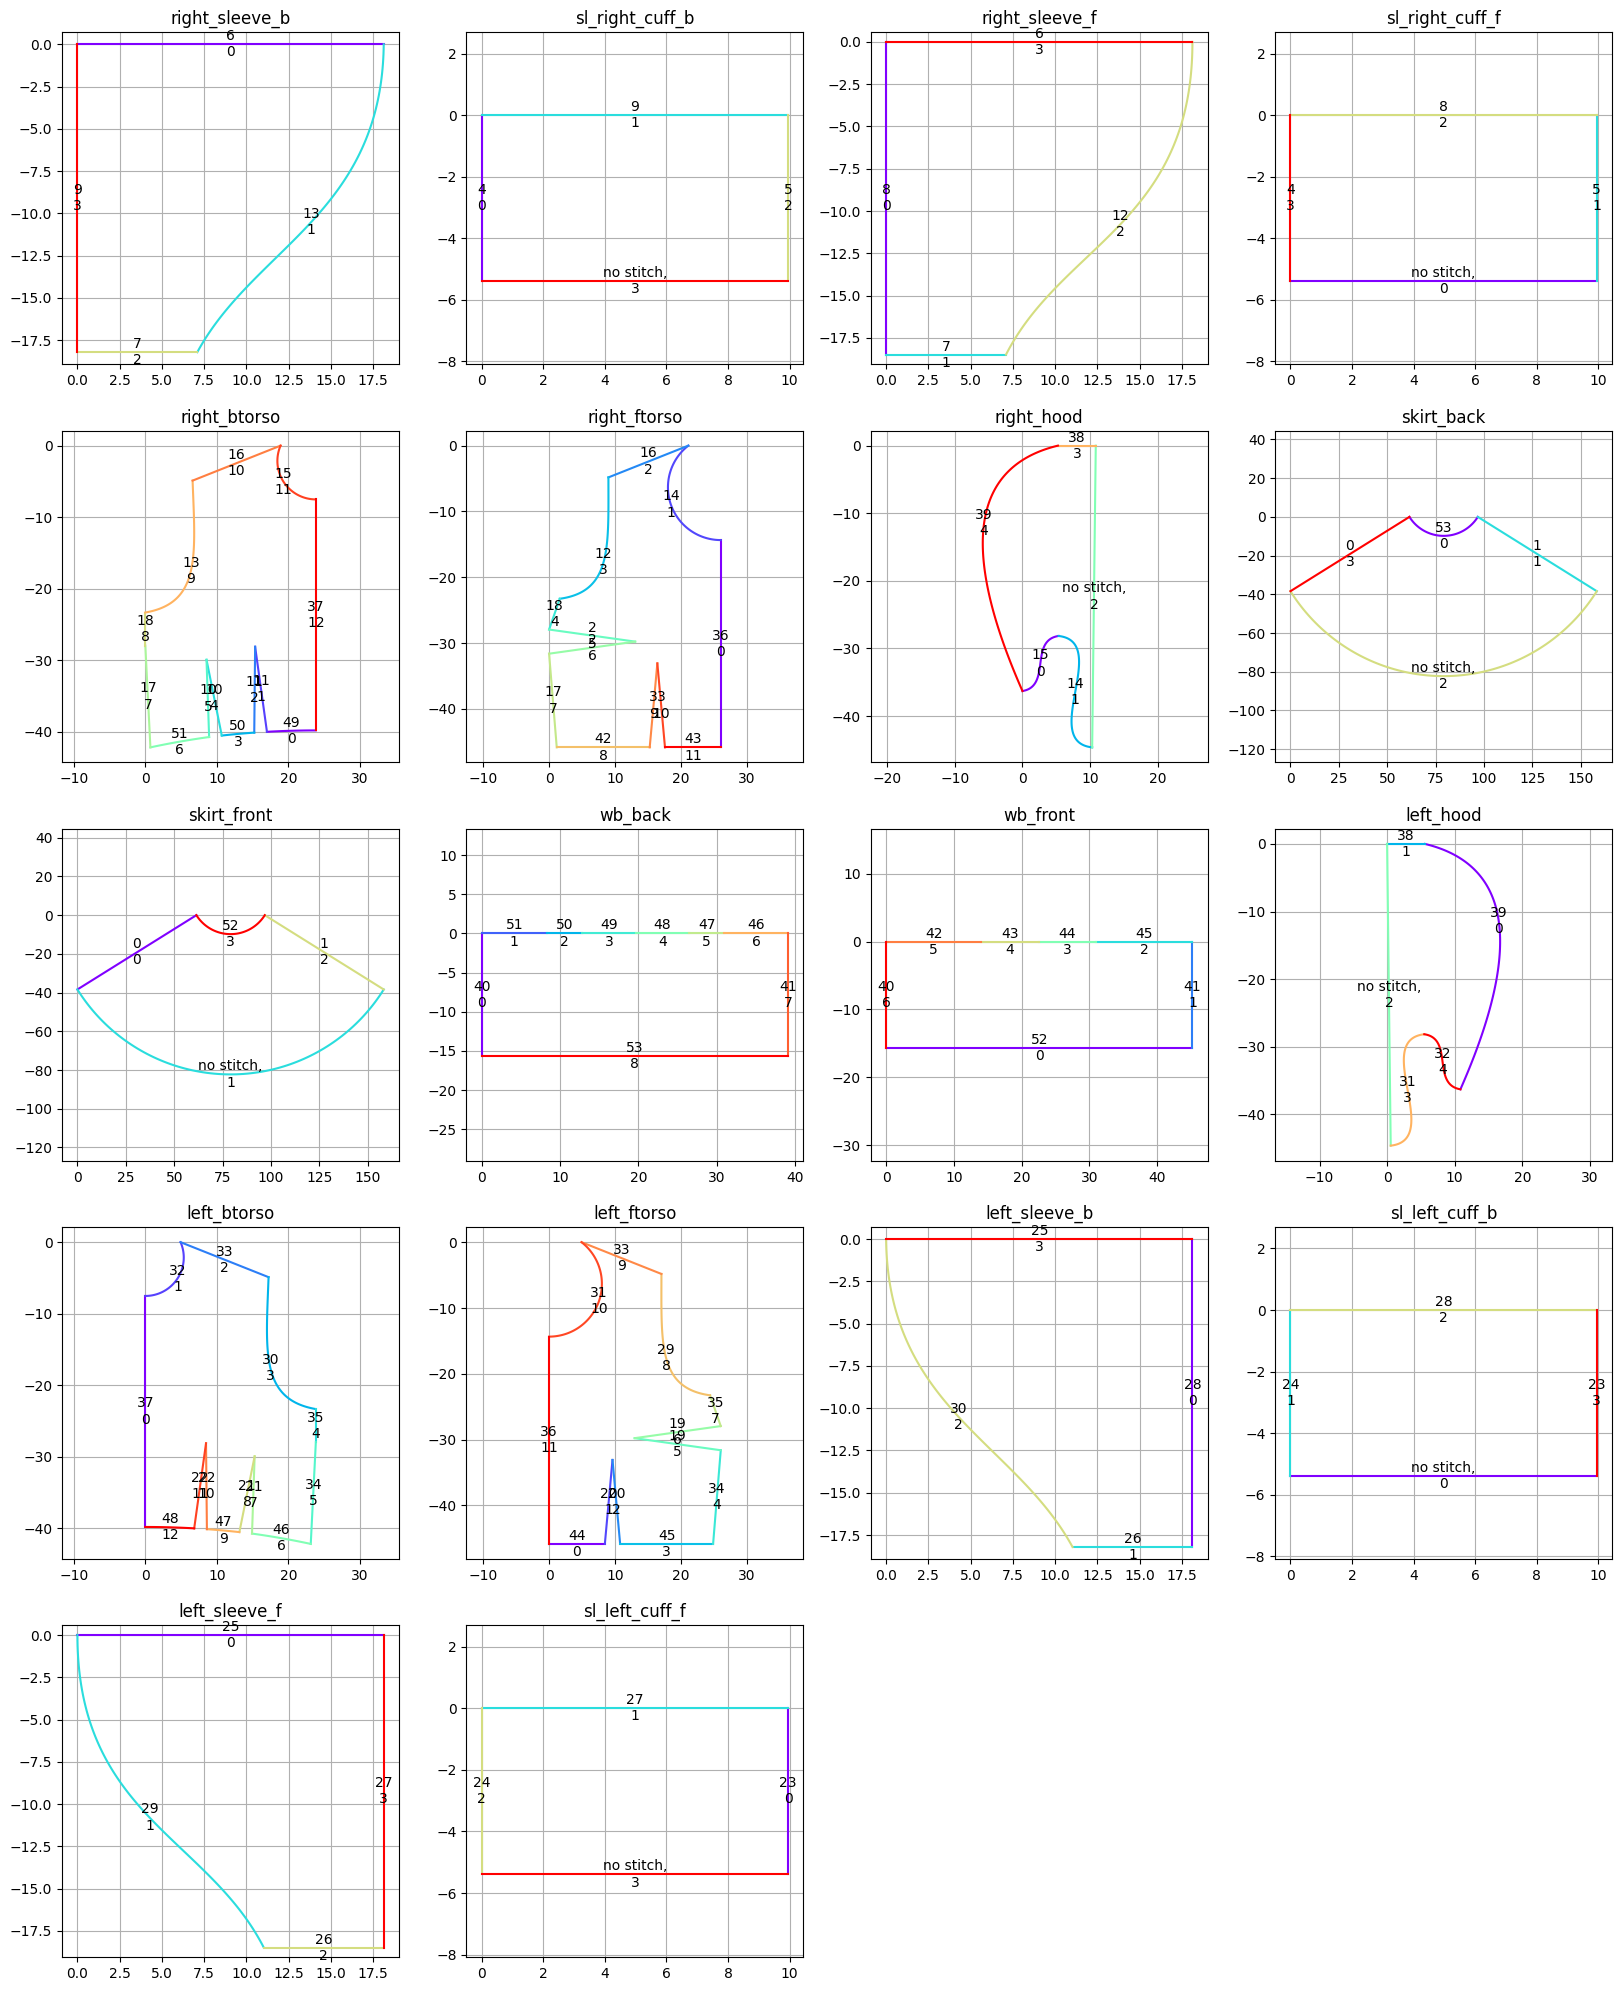

In [19]:
NROWs = int(np.ceil(np.sqrt(len(panel_svg_path_dict))))
NCOLs = int(np.ceil(len(panel_svg_path_dict) / NROWs))
FIGLEN = 5

plt.figure(figsize=(FIGLEN * NCOLs, FIGLEN * NROWs))

for i, (panel_name, path) in enumerate(panel_svg_path_dict.items()):
    ax = plt.subplot(NROWs, NCOLs, i+1)
    plot_panel_info(ax, panel_name, panel_svg_path_dict, stitch_dict)
plt.show()

In [48]:
path_2 = panel_svg_path_dict[list(panel_svg_path_dict.keys())[4]]
path_2

(Path(QuadraticBezier(start=(23.83805+39.808646982765154j), control=(20.41580365836496+39.808646950950624j), end=(17.003876502111655+40.001883388643314j)),
      Line(start=(17.003876502111655+40.001883388643314j), end=(15.351116538478411+28.112162252088922j)),
      Line(start=(15.351116538478411+28.112162252088922j), end=(15.22828367162682+40.115578277922495j)),
      QuadraticBezier(start=(15.22828367162682+40.115578277922495j), control=(12.956118484883692+40.27788904475859j), end=(10.688536931043377+40.52603265543496j)),
      Line(start=(10.688536931043377+40.52603265543496j), end=(8.555268374597688+29.93510240969932j)),
      Line(start=(8.555268374597688+29.93510240969932j), end=(8.92133247524254+40.732538923899206j)),
      QuadraticBezier(start=(8.92133247524254+40.732538923899206j), control=(4.806184540271747+41.30113271975075j), end=(0.7116916666666668+42.17753864510458j)),
      Line(start=(0.7116916666666668+42.17753864510458j), end=27.94367197843792j),
      Line(start=27

(np.float64(-0.04999999999999999),
 np.float64(1.0499999999999998),
 np.float64(-0.05000000000000002),
 np.float64(1.0500000000000003))

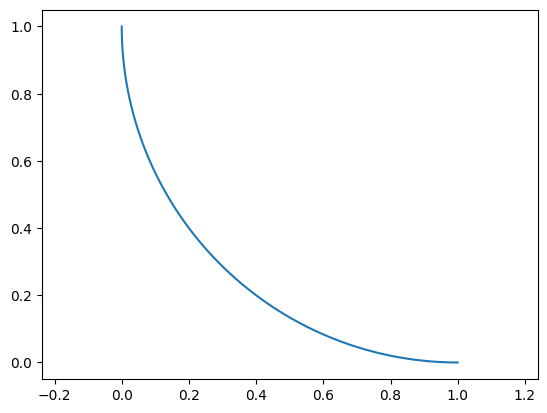

In [71]:
RAD = 1

arc = Arc(
    start=(0+1j),
    radius = RAD+RAD*1j,
    rotation = 0,
    large_arc = False,
    sweep = True,
    end = (1+0j)
)

sampled_points = np.array([
    [arc.point(t).real, arc.point(t).imag]
    for t in np.linspace(0, 1, 100)
])

plt.plot(sampled_points[:, 0], sampled_points[:, 1], '-')
plt.axis('equal')

Original Path: Path(QuadraticBezier(start=(23.83805+39.808646982765154j), control=(20.41580365836496+39.808646950950624j), end=(17.003876502111655+40.001883388643314j)),
     Line(start=(17.003876502111655+40.001883388643314j), end=(15.351116538478411+28.112162252088922j)),
     Line(start=(15.351116538478411+28.112162252088922j), end=(15.22828367162682+40.115578277922495j)),
     QuadraticBezier(start=(15.22828367162682+40.115578277922495j), control=(12.956118484883692+40.27788904475859j), end=(10.688536931043377+40.52603265543496j)),
     Line(start=(10.688536931043377+40.52603265543496j), end=(8.555268374597688+29.93510240969932j)),
     Line(start=(8.555268374597688+29.93510240969932j), end=(8.92133247524254+40.732538923899206j)),
     QuadraticBezier(start=(8.92133247524254+40.732538923899206j), control=(4.806184540271747+41.30113271975075j), end=(0.7116916666666668+42.17753864510458j)),
     Line(start=(0.7116916666666668+42.17753864510458j), end=27.94367197843792j),
     Line(st

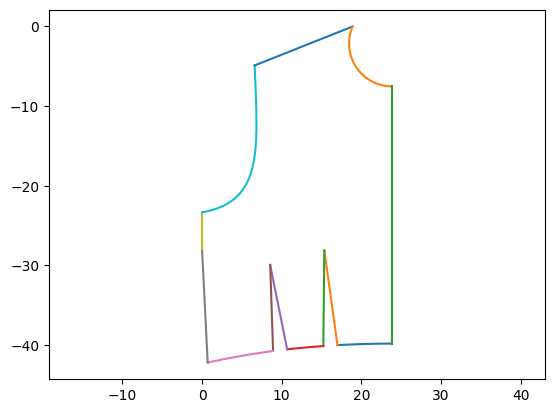

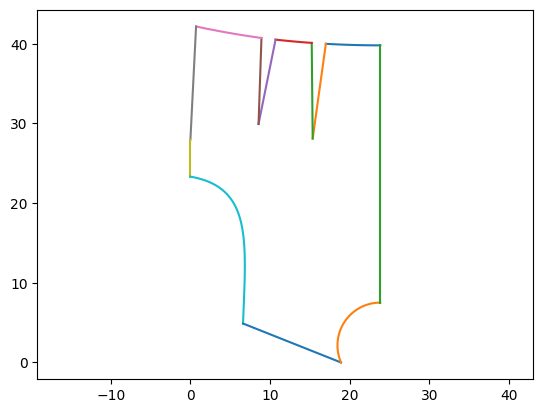

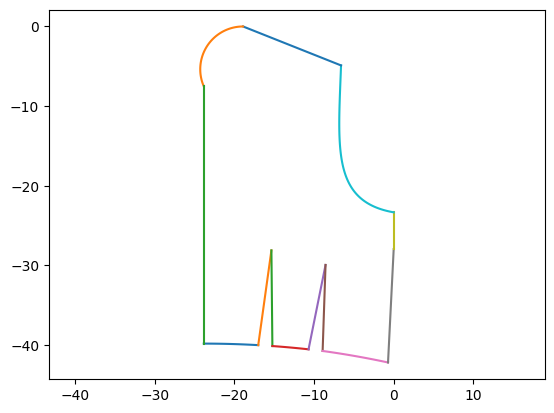

In [ ]:
import math
from svgpathtools import Path, Line, QuadraticBezier, CubicBezier, Arc

# --- Transformation Helpers ---

def reflect_x(z):
    """Reflect a complex number across the X-axis: (x, y) -> (x, -y)."""
    return z.conjugate()

def reflect_y(z):
    """Reflect a complex number across the Y-axis: (x, y) -> (-x, y)."""
    return -z.real + z.imag * 1j

def rotate(z, angle, origin=0):
    """
    Rotate a complex number z by an angle (in radians) around the given origin.
    """
    return origin + (z - origin) * complex(math.cos(angle), math.sin(angle))

# --- Segment Transformation Functions ---

def transform_segment(seg, transform_func, extra_transform=None):
    """
    Apply a transformation to a segment. The transform_func takes a complex number and returns a transformed one.
    If extra_transform is provided (for segments like Arc) it will be used to modify other properties.
    """
    # For Arc segments, we need to transform the start, end, and adjust sweep and rotation.
    if isinstance(seg, Arc):
        new_start = transform_func(seg.start)
        new_end = transform_func(seg.end)
        # For x-reflection, we invert the sweep; for y-reflection, the rotation angle changes sign.
        if extra_transform == 'reflect_x':
            new_sweep = not seg.sweep
            new_rotation = seg.rotation  # rotation remains the same for x-axis reflection
        elif extra_transform == 'reflect_y':
            new_sweep = seg.sweep
            new_rotation = -seg.rotation  # negate the rotation angle for y-axis reflection
        elif extra_transform == 'rotate':
            # When rotating, the arc's rotation is increased by the same angle.
            new_sweep = seg.sweep
            new_rotation = seg.rotation + transform_func(1).imag  # using imag part of transform(1) as angle
        else:
            new_sweep = seg.sweep
            new_rotation = seg.rotation
        return Arc(
            start=new_start,
            radius=seg.radius,  # assuming uniform transformation; non-uniform scaling would need more work
            rotation=new_rotation,
            large_arc=seg.large_arc,
            sweep=new_sweep,
            end=new_end
        )
    elif isinstance(seg, (Line, QuadraticBezier, CubicBezier)):
        # For these segments, just transform all control points
        # Segments have different numbers of control points; unpack them accordingly.
        points = [seg.start] + list(seg[1:])
        transformed_points = [transform_func(z) for z in points]
        return type(seg)(*transformed_points)
    else:
        # If segment type is not recognized, return it unchanged.
        return seg

def transform_path(path, transform_func, extra_transform=None):
    """Apply a transformation function to every segment in the path."""
    new_segments = [transform_segment(seg, transform_func, extra_transform) for seg in path]
    return Path(*new_segments)

# --- Reflection Functions ---

def reflect_path_x(path):
    """
    Reflect the entire path across the X-axis.
    For Arc segments, the sweep flag is inverted.
    """
    return transform_path(path, reflect_x, extra_transform='reflect_x')

def reflect_path_y(path):
    """
    Reflect the entire path across the Y-axis.
    For Arc segments, the rotation angle is negated.
    """
    return transform_path(path, reflect_y, extra_transform='reflect_y')

# --- Rotation Function ---

def rotate_path(path, angle, origin=0):
    """
    Rotate the entire path by a given angle (in radians) around the specified origin.
    For Arc segments, increase the arc's rotation by the same angle.
    """
    def rot_func(z):
        return rotate(z, angle, origin)
    # When rotating, for Arc segments we update the rotation parameter too.
    return transform_path(path, rot_func, extra_transform='rotate')

# --- Example Path ---
original_path = Path(
    QuadraticBezier(start=(23.83805+39.808646982765154j),
                    control=(20.41580365836496+39.808646950950624j),
                    end=(17.003876502111655+40.001883388643314j)),
    Line(start=(17.003876502111655+40.001883388643314j),
         end=(15.351116538478411+28.112162252088922j)),
    Line(start=(15.351116538478411+28.112162252088922j),
         end=(15.22828367162682+40.115578277922495j)),
    QuadraticBezier(start=(15.22828367162682+40.115578277922495j),
                    control=(12.956118484883692+40.27788904475859j),
                    end=(10.688536931043377+40.52603265543496j)),
    Line(start=(10.688536931043377+40.52603265543496j),
         end=(8.555268374597688+29.93510240969932j)),
    Line(start=(8.555268374597688+29.93510240969932j),
         end=(8.92133247524254+40.732538923899206j)),
    QuadraticBezier(start=(8.92133247524254+40.732538923899206j),
                    control=(4.806184540271747+41.30113271975075j),
                    end=(0.7116916666666668+42.17753864510458j)),
    Line(start=(0.7116916666666668+42.17753864510458j),
         end=27.94367197843792j),
    Line(start=27.94367197843792j,
         end=23.330221264450127j),
    CubicBezier(start=23.330221264450127j,
                control1=(7.776447999999999+21.955302764450124j),
                control2=(6.993121+15.431411264450126j),
                end=(6.6096499999999985+4.888741264450125j)),
    Line(start=(6.6096499999999985+4.888741264450125j),
         end=(18.908444674293094+0j)),
    Arc(start=(18.908444674293094+0j),
        radius=(5.374635716436847+5.374635716436847j),
        rotation=0,
        large_arc=False,
        sweep=False,
        end=(23.83805+7.516060573199454j)),
    Line(start=(23.83805+7.516060573199454j),
         end=(23.83805+39.808646982765154j))
)

# --- Apply Transformations ---

# Reflect against the X-axis
x_reflected = reflect_path_x(original_path)

# Reflect against the Y-axis
y_reflected = reflect_path_y(original_path)

# Rotate by 45 degrees (pi/4 radians) about the origin
rotated = rotate_path(original_path, math.pi / 4)

# --- Output (for debugging, you might print or use an SVG renderer) ---
print("Original Path:", original_path)
print("X-axis Reflected Path:", x_reflected)
print("Y-axis Reflected Path:", y_reflected)
print("Rotated Path (45°):", rotated)

plot_svg_path(original_path)
plt.show()

plot_svg_path(x_reflected)

# plot_svg_path(x_reflected_path)
# plt.show()

In [ ]:





    edge_width=2,




    vector_list=None,  # ✅ 벡터 추가




    vector_color_list=None,  # ✅ 벡터 색상 추가




    vector_width=3,  # ✅ 벡터 선 두께 설정




    show=True,

In [45]:

def plot_svg_path(
    svg_path,
    N_SAMPLES: int = 100,
) :
    for edge_idx, edge in enumerate(svg_path):
        segment_points = np.array([
            [edge.point(t).real, edge.point(t).imag]
            for t in np.linspace(0, 1, N_SAMPLES)
        ])
        plt.plot(
            segment_points[:, 0],
            segment_points[:, 1] * -1,
            '-',
        )
        plt.axis('equal')
        
        

# def plot_svg_path(
#     svg_path,
#     stitch_dict = None,
#     panel_name = None,
#     ax = None,
#     N_SAMPLES: int = 100,
# ):
#     # path = panel_svg_path_dict[panel_name][0]
    
#     if ax is None:
#         ax = plt.subplot(1, 1, 1)
#     ax.set_title(panel_name)
#     ax.axis('equal')
#     ax.grid(True)

#     colors = plt.cm.rainbow(np.linspace(0, 1, len(path)))

#     for edge_idx, segment in enumerate(svg_path):
#         segment_points = np.array([
#             [segment.point(t).real, segment.point(t).imag]
#             for t in np.linspace(0, 1, N_SAMPLES)
#         ])
        
#         ax.plot(
#             segment_points[:, 0],
#             segment_points[:, 1] * -1,
#             '-', color=colors[edge_idx]
#         )
        
#         segment_center = segment.point(0.5)
#         segment_center = np.array([segment_center.real, segment_center.imag])
    
        
#         if stitch_dict is not None:
#             has_stitch = False
        
#             for stitch_idx, stitch_edges in stitch_dict.items():
#                 for edge_info in stitch_edges:
#                     if not isinstance(edge_info, dict):
#                         # print(edge_info)
#                         continue
#                     if edge_info['edge'] == edge_idx and edge_info['panel'] == panel_name:
#                         has_stitch = True
#                         ax.text(
#                             segment_center[0],
#                             -segment_center[1],
#                             f"{stitch_idx}\n{edge_info['edge']}",
#                             ha='center', va='center'
#                         )

#             if not has_stitch:
#                 ax.text(
#                     segment_center[0],
#                     -segment_center[1],
#                     f"no stitch,\n{edge_idx}",
#                     ha='center', va='center'
#                 )

In [25]:
from svgpathtools import Path, Line, CubicBezier, QuadraticBezier, Arc

# Function to reflect a path across the X-axis
def reflect_x(path):
    return Path(*(transform_segment_x(seg) for seg in path))

# Function to reflect a path across the Y-axis
def reflect_y(path):
    return Path(*(transform_segment_y(seg) for seg in path))

# Helper function to reflect a segment across the X-axis
def transform_segment_x(seg):
    if isinstance(seg, Arc):
        return Arc(
            start=seg.start.conjugate(),
            radius=seg.radius,
            rotation=seg.rotation,  # Rotation stays the same
            large_arc=seg.large_arc,
            sweep=not seg.sweep,  # Invert the sweep flag
            end=seg.end.conjugate()
        )
    elif isinstance(seg, (Line, QuadraticBezier, CubicBezier)):
        return type(seg)(*[c.conjugate() for c in [seg.start, *seg]])
    else:
        return seg  # Return unchanged if unrecognized

# Helper function to reflect a segment across the Y-axis
def transform_segment_y(seg):
    if isinstance(seg, Arc):
        return Arc(
            start=-seg.start.real + seg.start.imag * 1j,
            radius=seg.radius,
            rotation=-seg.rotation,  # Negate the rotation
            large_arc=seg.large_arc,
            sweep=seg.sweep,  # Sweep flag remains the same
            end=-seg.end.real + seg.end.imag * 1j
        )
    elif isinstance(seg, (Line, QuadraticBezier, CubicBezier)):
        return type(seg)(*[-c.real + c.imag * 1j for c in [seg.start, *seg]])
    else:
        return seg  # Return unchanged if unrecognized

# Example Path containing an Arc
original_path = Path(
    QuadraticBezier(start=(23.83805+39.808646982765154j), control=(20.41580365836496+39.808646950950624j), end=(17.003876502111655+40.001883388643314j)),
    Line(start=(17.003876502111655+40.001883388643314j), end=(15.351116538478411+28.112162252088922j)),
    Arc(start=(18.908444674293094+0j), radius=(5.374635716436847+5.374635716436847j), rotation=0, large_arc=False, sweep=False, end=(23.83805+7.516060573199454j))
)

# Apply reflections
x_reflected_path = reflect_x(original_path)  # X-axis reflection
y_reflected_path = reflect_y(original_path)  # Y-axis reflection

# Print results
print("Original Path:", original_path)
print("X-axis Reflected Path:", x_reflected_path)
print("Y-axis Reflected Path:", y_reflected_path)

TypeError: __init__() takes 4 positional arguments but 5 were given